# Formula 1 Lap Time Prediction using Machine Learning

This project builds a machine learning model to predict Formula 1 lap times using race data obtained through the FastF1 library.

The goal is to understand how different race factors such as tyre life, fuel load, track evolution, and traffic influence lap performance.

Dataset Source: FastF1 (official F1 timing data)

Techniques used:
- Feature engineering
- Regression modelling
- Random Forest
- Data visualisation

## 1. Installing Required Libraries

This project requires several Python libraries:

- fastf1 → access official F1 timing data
- pandas → data manipulation
- numpy → numerical operations
- scikit-learn → machine learning models
- matplotlib & seaborn → visualisation

In [ ]:
%pip install fastf1 pandas numpy scikit-learn matplotlib seaborn

## 2. Importing Libraries

We import the necessary Python libraries required for:

- data processing
- machine learning
- visualisation

In [55]:
import os
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

## 3. Enabling FastF1 Cache

FastF1 downloads session data from the Formula 1 timing API.

To avoid repeatedly downloading the same data, a **cache directory** is created.  
This stores downloaded data locally and speeds up future runs.

In [56]:
# Create cache directory if it does not exist
cache_dir = "cache"

if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# Enable FastF1 caching
fastf1.Cache.enable_cache(cache_dir)

print("Cache enabled successfully.")

Cache enabled successfully.


## 4. Loading Race Data

We load a specific race session from the Formula 1 season.

Session Types:
- FP1 / FP2 / FP3 → Practice
- Q → Qualifying
- R → Race

For this project we use the **race session** for the entire 2021 season, since it contains realistic race conditions.

In [ ]:
year = 2021

schedule = fastf1.get_event_schedule(year)

all_laps = []

for race in schedule['EventName']:
    
    try:
        print("Loading:", race)
        
        # Load session
        session = fastf1.get_session(year, race, 'R')
        session.load()

        # Retrieve lap data
        laps = session.laps.copy()
        laps['Race'] = race

        all_laps.append(laps)

    except Exception as e:
        print("Skipped:", race, "|", e)

season_laps = pd.concat(all_laps, ignore_index=True)

print("Total laps collected:", len(season_laps))
season_laps.head()

## 5. Selecting Relevant Features

The FastF1 dataset contains many columns.  
We select the variables most relevant for lap time prediction:

- Driver → driver identifier
- LapNumber → lap number during the race
- Stint → tyre stint number
- Compound → tyre compound
- TyreLife → number of laps on current tyre
- TrackStatus → race conditions
- Position → driver position
- LapTime → total lap time

In [58]:
laps = season_laps[[
    'Race',
    'Driver',
    'LapNumber',
    'Stint',
    'Compound',
    'TyreLife',
    'TrackStatus',
    'Position',
    'LapTime'
]]

# Remove rows with missing values
laps = laps.dropna()

laps

,Race,Driver,LapNumber,Stint,Compound,TyreLife,TrackStatus,Position,LapTime
0,Pre-Season Test,VER,1.0,1.0,MEDIUM,4.0,12,2.0,0 days 00:01:42.612000
1,Pre-Season Test,VER,2.0,1.0,MEDIUM,5.0,1,2.0,0 days 00:01:41.750000
2,Pre-Season Test,VER,3.0,1.0,MEDIUM,6.0,1,2.0,0 days 00:01:41.271000
3,Pre-Season Test,VER,4.0,1.0,MEDIUM,7.0,1,2.0,0 days 00:01:41.125000
4,Pre-Season Test,VER,5.0,1.0,MEDIUM,8.0,1,2.0,0 days 00:01:41.482000
...,...,...,...,...,...,...,...,...,...
24796,Abu Dhabi Grand Prix,GIO,29.0,2.0,HARD,12.0,1,13.0,0 days 00:01:29.694000
24797,Abu Dhabi Grand Prix,GIO,30.0,2.0,HARD,13.0,1,13.0,0 days 00:01:29.775000
24798,Abu Dhabi Grand Prix,GIO,31.0,2.0,HARD,14.0,1,13.0,0 days 00:01:29.505000
24799,Abu Dhabi Grand Prix,GIO,32.0,2.0,HARD,15.0,1,13.0,0 days 00:01:29.596000


## 6. Converting Lap Time to Seconds

Lap times in FastF1 are stored as timedelta objects.

Machine learning models require numeric values, so we convert lap time into seconds.

In [59]:
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

laps[['LapTime','LapTimeSeconds']].head()

,LapTime,LapTimeSeconds
0,0 days 00:01:42.612000,102.612
1,0 days 00:01:41.750000,101.750
2,0 days 00:01:41.271000,101.271
3,0 days 00:01:41.125000,101.125
4,0 days 00:01:41.482000,101.482


## 7. Feature Engineering

We create additional features to improve prediction accuracy.

### Fuel Load Estimate
Cars start the race heavy with fuel and gradually get lighter.

### Track Evolution
As more cars drive on the track, grip improves.

### Tyre Degradation
Tyre performance decreases as tyre life increases.

### Traffic Indicator
Drivers behind other cars experience aerodynamic disturbance.

In [60]:
# Estimate fuel load
# assuming 110kg starting fuel and 1.8kg burn per lap
laps['FuelLoadEstimate'] = 110 - (laps['LapNumber'] * 1.8)

# Track Evolution
laps['TrackEvolution'] = laps['LapNumber'] / laps['LapNumber'].max()

# Tyre Degradation
laps['TyreDeg'] = laps['TyreLife'] ** 1.3

# Traffic Feature
laps['Traffic'] = (laps['Position'] > 1).astype(int)

laps.head()

,Race,Driver,LapNumber,Stint,Compound,TyreLife,TrackStatus,Position,LapTime,LapTimeSeconds,FuelLoadEstimate,TrackEvolution,TyreDeg,Traffic
0,Pre-Season Test,VER,1.0,1.0,MEDIUM,4.0,12,2.0,0 days 00:01:42.612000,102.612,108.2,0.012821,6.062866,1
1,Pre-Season Test,VER,2.0,1.0,MEDIUM,5.0,1,2.0,0 days 00:01:41.750000,101.750,106.4,0.025641,8.103283,1
2,Pre-Season Test,VER,3.0,1.0,MEDIUM,6.0,1,2.0,0 days 00:01:41.271000,101.271,104.6,0.038462,10.270619,1
3,Pre-Season Test,VER,4.0,1.0,MEDIUM,7.0,1,2.0,0 days 00:01:41.125000,101.125,102.8,0.051282,12.549530,1
4,Pre-Season Test,VER,5.0,1.0,MEDIUM,8.0,1,2.0,0 days 00:01:41.482000,101.482,101.0,0.064103,14.928528,1


## 8. Removing Outliers

Extremely slow laps can occur due to:
- pit stops
- safety cars
- mechanical issues

We remove the slowest 1% of laps to reduce noise.

In [61]:
laps = laps[laps['LapTimeSeconds'] < laps['LapTimeSeconds'].quantile(0.99)]

print("Remaining laps:", len(laps))

Remaining laps: 24103


## 9. Encoding Categorical Variables

Machine learning models cannot process text data.

We convert categorical variables such as:
- Driver
- Tyre Compound

into numerical features using **one-hot encoding**.

In [62]:
laps_encoded = pd.get_dummies(
    laps,
    columns=['Driver', 'Compound', 'Race'],
    drop_first=True
)

laps_encoded.head()

,LapNumber,Stint,TyreLife,TrackStatus,Position,LapTime,LapTimeSeconds,FuelLoadEstimate,TrackEvolution,TyreDeg,...,Race_Portuguese Grand Prix,Race_Pre-Season Test,Race_Qatar Grand Prix,Race_Russian Grand Prix,Race_Saudi Arabian Grand Prix,Race_Spanish Grand Prix,Race_Styrian Grand Prix,Race_São Paulo Grand Prix,Race_Turkish Grand Prix,Race_United States Grand Prix
0,1.0,1.0,4.0,12,2.0,0 days 00:01:42.612000,102.612,108.2,0.012821,6.062866,...,False,True,False,False,False,False,False,False,False,False
1,2.0,1.0,5.0,1,2.0,0 days 00:01:41.750000,101.750,106.4,0.025641,8.103283,...,False,True,False,False,False,False,False,False,False,False
2,3.0,1.0,6.0,1,2.0,0 days 00:01:41.271000,101.271,104.6,0.038462,10.270619,...,False,True,False,False,False,False,False,False,False,False
3,4.0,1.0,7.0,1,2.0,0 days 00:01:41.125000,101.125,102.8,0.051282,12.549530,...,False,True,False,False,False,False,False,False,False,False
4,5.0,1.0,8.0,1,2.0,0 days 00:01:41.482000,101.482,101.0,0.064103,14.928528,...,False,True,False,False,False,False,False,False,False,False


## 10. Defining Features and Target

X → model inputs (features)  
y → model output (target variable)

The target variable for prediction is **LapTimeSeconds**.

In [63]:
X = laps_encoded.drop(['LapTime','LapTimeSeconds'], axis=1)
y = laps_encoded['LapTimeSeconds']

print("Features:", X.shape)


Features: (24103, 54)


## 11. Train-Test Split

We split the dataset into:

- Training set (80%)
- Testing set (20%)

The training set is used to train the model.  
The testing set evaluates model performance on unseen data.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=44
)

## 12. Training the Machine Learning Model

We use a **Random Forest Regressor**, which is an ensemble learning method that combines multiple decision trees.

Advantages:
- Handles non-linear relationships
- Robust to noise
- Works well with tabular data

In [72]:
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    random_state=44,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training complete")

Model training complete


## 13. Predicting Lap Times

In [76]:
predictions = model.predict(X_test)
predictions[:10]

array([ 81.44520807,  90.828776  ,  82.82727893,  78.01606383,
        75.3483957 ,  84.17907996, 102.78965576,  73.18985792,
        71.6661938 , 118.14365   ])

## 14. Model Evaluation

We evaluate the model using:

MAE (Mean Absolute Error) → average prediction error in seconds  
R² Score → proportion of variance explained by the model

In [77]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model Performance")
print("------------------")
print("MAE:", round(mae,3),"seconds")
print("R2 Score:", round(r2,3))

Model Performance
------------------
MAE: 1.137 seconds
R2 Score: 0.962


## 15. Feature Importance

Random Forest models allow us to evaluate which features contribute most to lap time prediction.

In [78]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head()

,Feature,Importance
3,TrackStatus,0.201049
50,Race_Styrian Grand Prix,0.106323
33,Race_Austrian Grand Prix,0.102104
37,Race_Dutch Grand Prix,0.070578
51,Race_São Paulo Grand Prix,0.067713


## 16. Features Affecting Lap Times

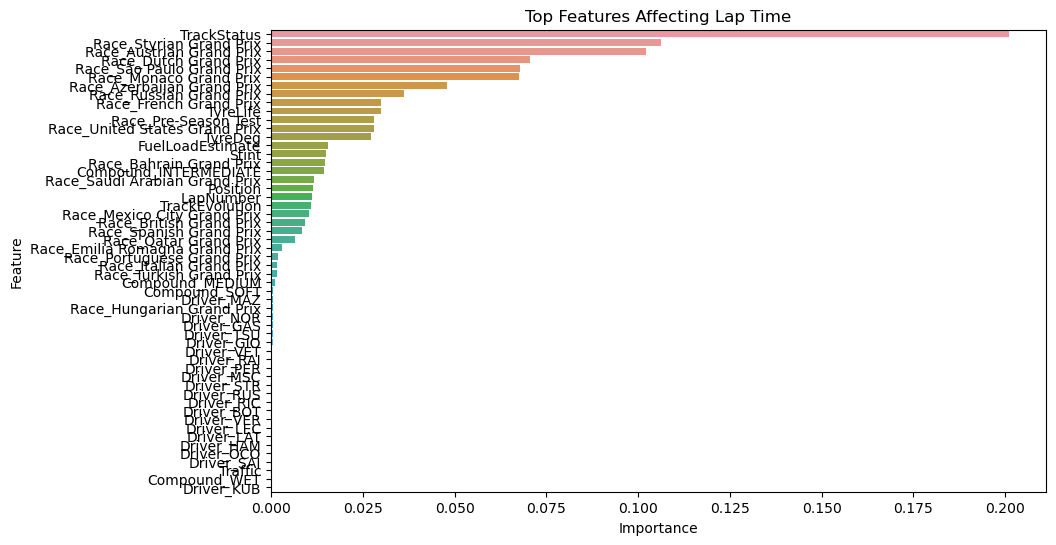

In [79]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Affecting Lap Time")
plt.show()

## 17. Impact of Tyre Degradation on Lap Times

c:\Users\roy_q\anaconda3\envs\pyTF\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\roy_q\anaconda3\envs\pyTF\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


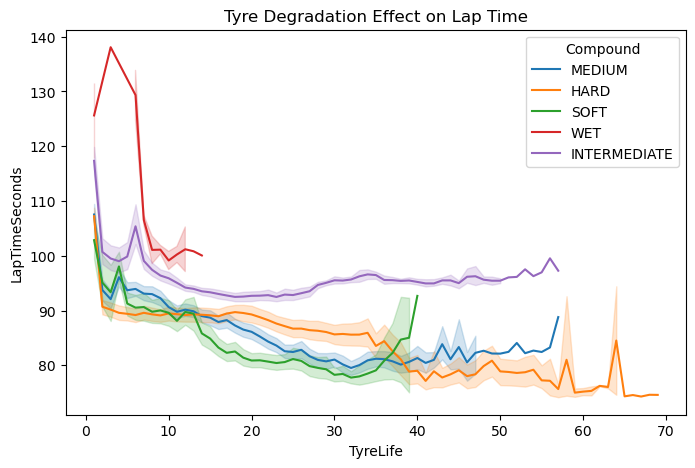

In [80]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=laps,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Compound"
)

plt.title("Tyre Degradation Effect on Lap Time")
plt.show()

## 18. Prediction vs Actual Lap Times

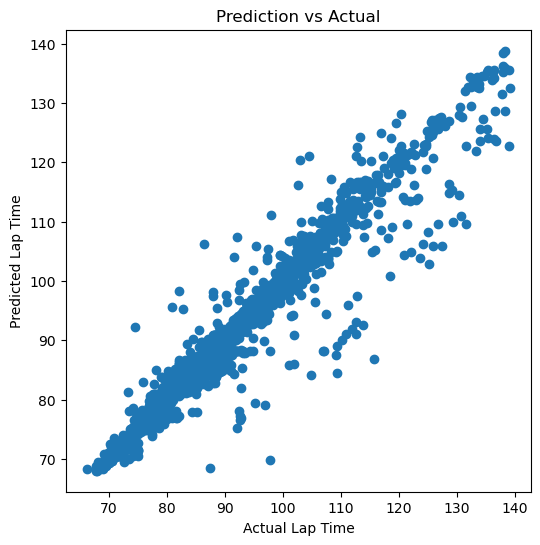

In [81]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")

plt.title("Prediction vs Actual")

plt.show()

## Conclusion

This project demonstrated how machine learning can be applied to motorsport analytics.

Key steps included:
- Extracting race data using FastF1
- Feature engineering for race conditions
- Training a regression model
- Evaluating prediction performance

The model achieved strong performance, explaining a large proportion of lap time variance.

Future improvements could include:
- using multiple race sessions
- incorporating weather data
- using gradient boosting models